# TraceWin distribution viewer

This notebook reads TraceWin binary `.dst` distributions and plots the transverse phase spaces.

It uses fixed paths: one input distribution, all intermediate `.dst` files inside `calc/`, and the final `part_dtl1.dst`.
Run all cells after each TraceWin/PARTRAN run so the files are reloaded from disk.

In [1]:
# Basic imports.
# pathlib handles file paths cleanly; numpy/pandas/matplotlib are used for data and plots.
import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# pyTraceWin_wrapper contains the Dst reader used to load TraceWin binary .dst files.
TRACEWIN_DIR = Path('/mnt/shared_volume/FEDERICO_TESI/beam_optimization/env/tracewin_env/tracewin')
sys.path.insert(0, str(TRACEWIN_DIR))
from pyTraceWin_wrapper.files import Dst

# Fixed TraceWin run paths.
# CALC_DIR is the folder refreshed by TraceWin/PARTRAN after a run.
#CALC_DIR = Path('/mnt/shared_volume/FEDERICO_TESI/DANIELE/TRACEWIN_WORKSPACE_test/TRACEWIN_WORKSPACE_0/calc')
#DST_INPUT = Path('/mnt/shared_volume/FEDERICO_TESI/DANIELE/TRACEWIN_WORKSPACE_test/TRACEWIN_WORKSPACE_0/16O5.dst')
CALC_DIR = Path('/mnt/shared_volume/FEDERICO_TESI/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/calc')
DST_INPUT = Path('/mnt/shared_volume/FEDERICO_TESI/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/16O5.dst')
DST_OUTPUT = CALC_DIR / 'part_dtl1.dst'
PARTRAN_FILE = CALC_DIR / 'partran1.out'

# Print the exact files used, so it is obvious which TraceWin run is being plotted.
print(f'CALC_DIR    = {CALC_DIR}')
print(f'DST_INPUT   = {DST_INPUT}')
print(f'DST_OUTPUT  = {DST_OUTPUT}')
print(f'PARTRAN_OUT = {PARTRAN_FILE}')

CALC_DIR    = /mnt/shared_volume/FEDERICO_TESI/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/calc
DST_INPUT   = /mnt/shared_volume/FEDERICO_TESI/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/16O5.dst
DST_OUTPUT  = /mnt/shared_volume/FEDERICO_TESI/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/calc/part_dtl1.dst
PARTRAN_OUT = /mnt/shared_volume/FEDERICO_TESI/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/calc/partran1.out


In [2]:
def natural_key(path):
    # Sort filenames naturally: 2.dst comes before 11.dst.
    parts = re.split(r'(\d+)', Path(path).name)
    return [int(part) if part.isdigit() else part.lower() for part in parts]


def read_npart_simulated(partran_file):
    # Read the number of simulated macro-particles from the partran1.out header.
    with open(partran_file) as f:
        f.readline()
        values = f.readline().split()
    return int(values[-1])


NPART_SIMULATED = read_npart_simulated(PARTRAN_FILE)

# Intermediate distributions are every .dst file written in calc/ by PLOT_DST,
# excluding TraceWin's standard input/output names.
intermediate_files = [
    path for path in sorted(CALC_DIR.glob('*.dst'), key=natural_key)
    if path.name not in {'part_rfq.dst', 'part_dtl1.dst'}
]

# Plot order: reservoir input, PLOT_DST snapshots, final output.
distribution_files = [DST_INPUT, *intermediate_files, DST_OUTPUT]

distributions = []
for path in distribution_files:
    role = 'input' if path == DST_INPUT else 'output' if path == DST_OUTPUT else 'intermediate'

    # Figure title: explicit names for the endpoints; raw filename for intermediate PLOT_DST files.
    display_title = {
        'input': 'Input distribution',
        'output': 'Output distribution',
        'intermediate': path.name,
    }[role]

    distributions.append({
        'title': display_title,
        'filename': path.name,
        'role': role,
        'path': path,
        'dst': Dst(str(path)),
    })

print(f'NPART_SIMULATED = {NPART_SIMULATED:,}')
print('Loaded distributions:')
for item in distributions:
    dst = item['dst']
    modified = pd.Timestamp(item['path'].stat().st_mtime, unit='s')
    print(f"  {item['title']:<20} {item['filename']:<14} {item['role']:<12} {dst.Np:>10,} particles   modified: {modified}")

NPART_SIMULATED = 10,000
Loaded distributions:
  Input distribution   16O5.dst       input         2,280,258 particles   modified: 2026-06-22 12:53:38.464639902
  1.dst                1.dst          intermediate     10,000 particles   modified: 2026-06-22 12:57:07.630528212
  2.dst                2.dst          intermediate     10,000 particles   modified: 2026-06-22 12:57:07.871529341
  3.dst                3.dst          intermediate     10,000 particles   modified: 2026-06-22 12:57:08.037529945
  4.dst                4.dst          intermediate     10,000 particles   modified: 2026-06-22 12:57:09.335535526
  5.dst                5.dst          intermediate     10,000 particles   modified: 2026-06-22 12:57:10.210539341
  6.dst                6.dst          intermediate     10,000 particles   modified: 2026-06-22 12:57:11.468544483
  7.dst                7.dst          intermediate     10,000 particles   modified: 2026-06-22 12:57:11.604545116
  8.dst                8.dst          int

In [3]:
def phase_space_plots(dst, title, aper_mm=None, bins=200):
    # Plot x-y, x-x', and y-y' projections for one TraceWin distribution.
    # TraceWin stores x/y in metres and xp/yp in radians; convert to mm/mrad for plotting.
    x = dst['x'] * 1e3
    xp = dst['xp'] * 1e3
    y = dst['y'] * 1e3
    yp = dst['yp'] * 1e3

    panels = [
        (x, y, 'x [mm]', 'y [mm]', 'x-y'),
        (x, xp, 'x [mm]', "x' [mrad]", "x-x'"),
        (y, yp, 'y [mm]', "y' [mrad]", "y-y'"),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    fig.suptitle(title, fontsize=12)

    for i, (ax, (cx, cy, lx, ly, subtitle)) in enumerate(zip(axes, panels)):
        # Use a log-density map so dense cores and sparse halo are visible together.
        h, xedge, yedge = np.histogram2d(cx, cy, bins=bins)
        h_log = np.log1p(h)
        h_log[h_log == 0] = np.nan

        im = ax.pcolormesh(xedge, yedge, h_log.T, cmap='Blues', shading='auto')

        # Black dashed axes mark reference zero; red cross is the centroid.
        ax.axhline(0, color='black', lw=0.8, linestyle='--')
        ax.axvline(0, color='black', lw=0.8, linestyle='--')
        ax.plot(np.mean(cx), np.mean(cy), marker='+', color='red', markersize=12, mew=2)

        # In the x-y panel, draw the circular aperture from partran1.out.
        if i == 0 and aper_mm is not None:
            pipe = plt.Circle((0, 0), aper_mm, fill=False, color='red', linewidth=1.5)
            ax.add_patch(pipe)
            ax.set_aspect('equal')
            ax.set_xlim(-aper_mm, aper_mm)
            ax.set_ylim(-aper_mm, aper_mm)

        ax.set_xlabel(lx, fontsize=9)
        ax.set_ylabel(ly, fontsize=9)
        ax.set_title(subtitle, fontsize=10)
        ax.tick_params(labelsize=8)

        cb = fig.colorbar(im, ax=ax, pad=0.02, fraction=0.046)
        cb.set_label('log(counts+1)', fontsize=7)
        cb.ax.tick_params(labelsize=6)

    plt.tight_layout()
    plt.show()

In [4]:
# partran1.out contains element-by-element beam statistics.
# We use it here for z positions and for the aperture column in the x-y plots.
df = pd.read_csv(PARTRAN_FILE, sep=r'\s+', header=0, skiprows=9)
z = df['z(m)']

print(f'Loaded {len(df)} rows from {PARTRAN_FILE.name}')

Loaded 691 rows from partran1.out


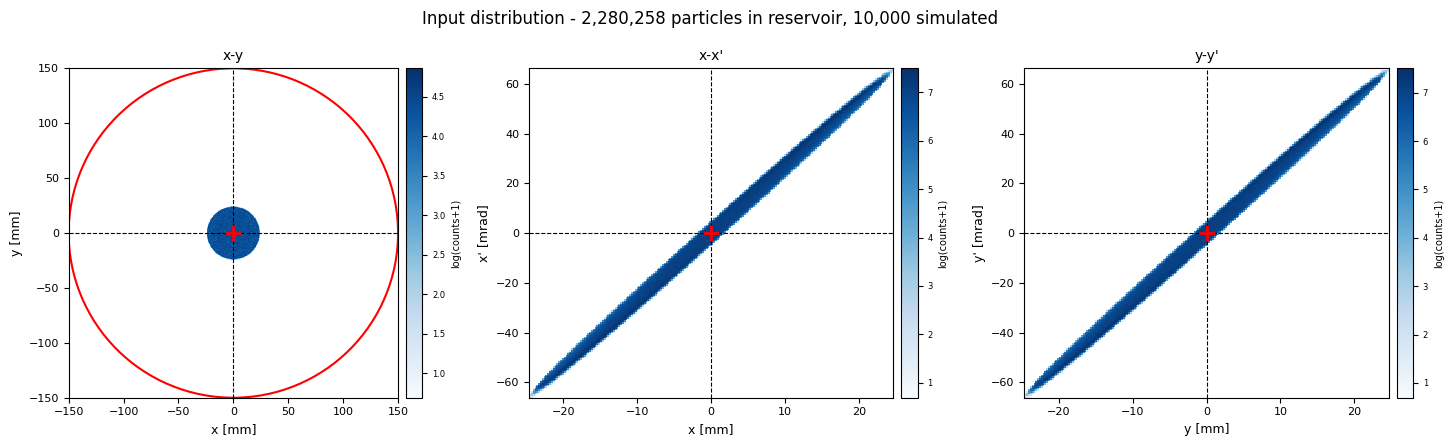

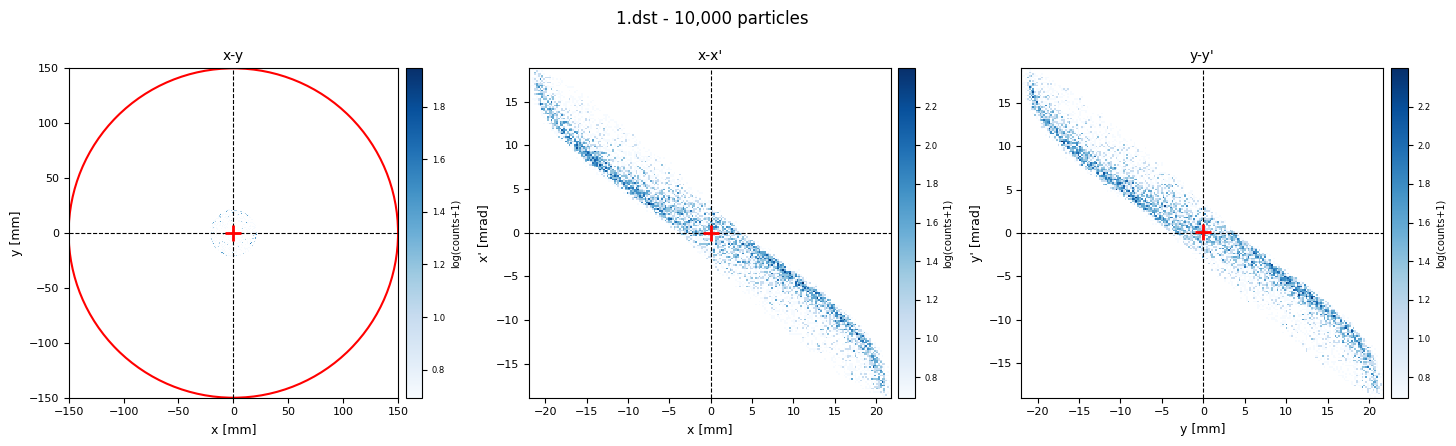

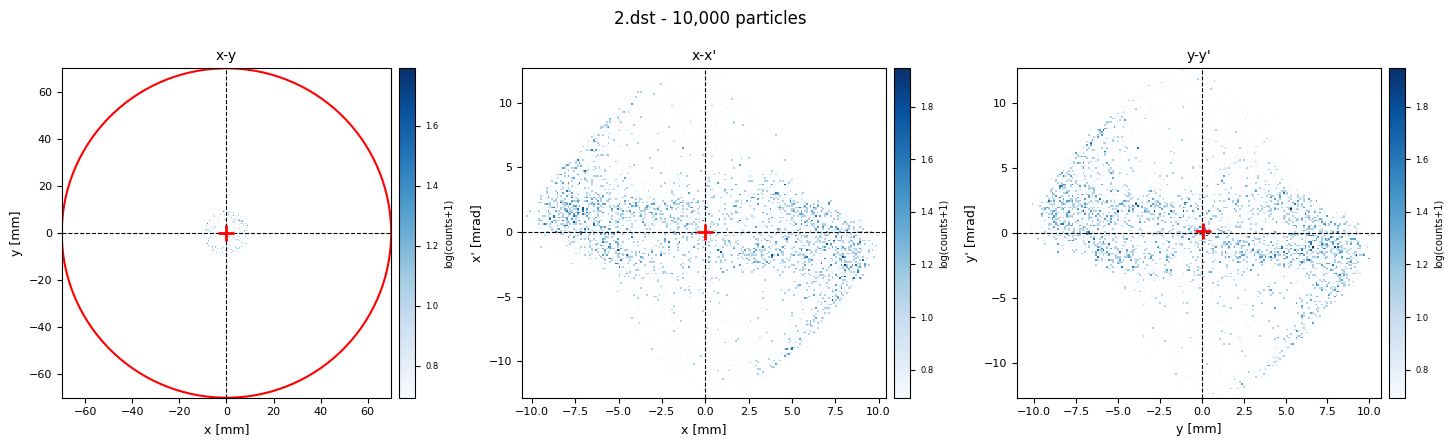

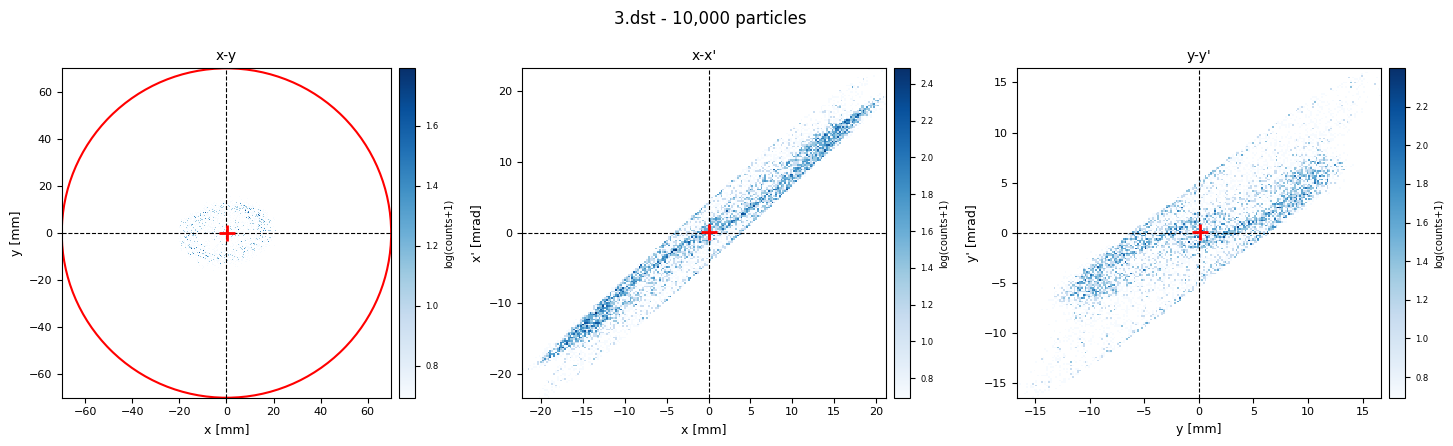

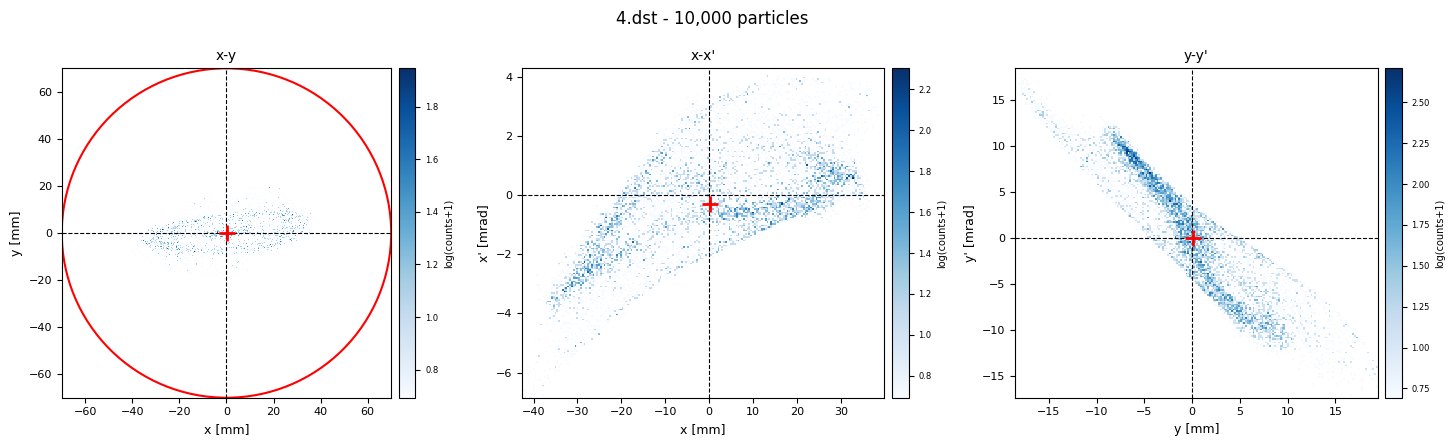

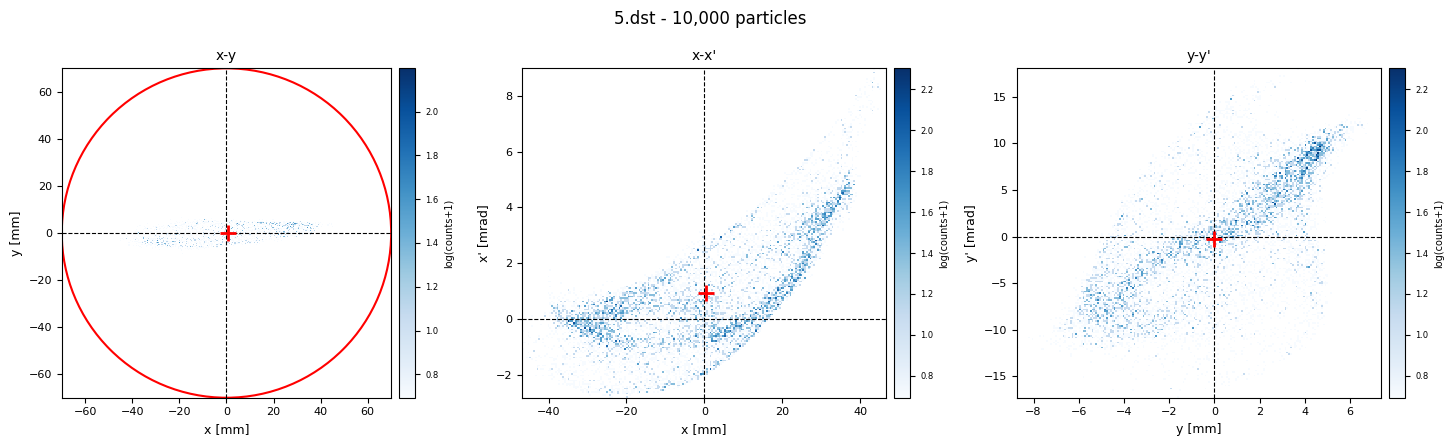

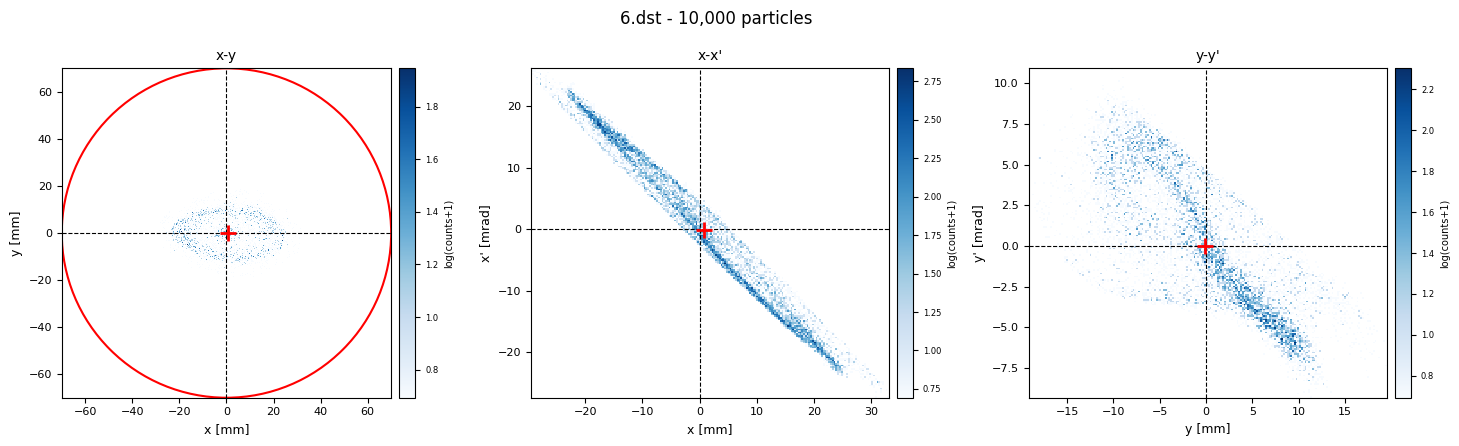

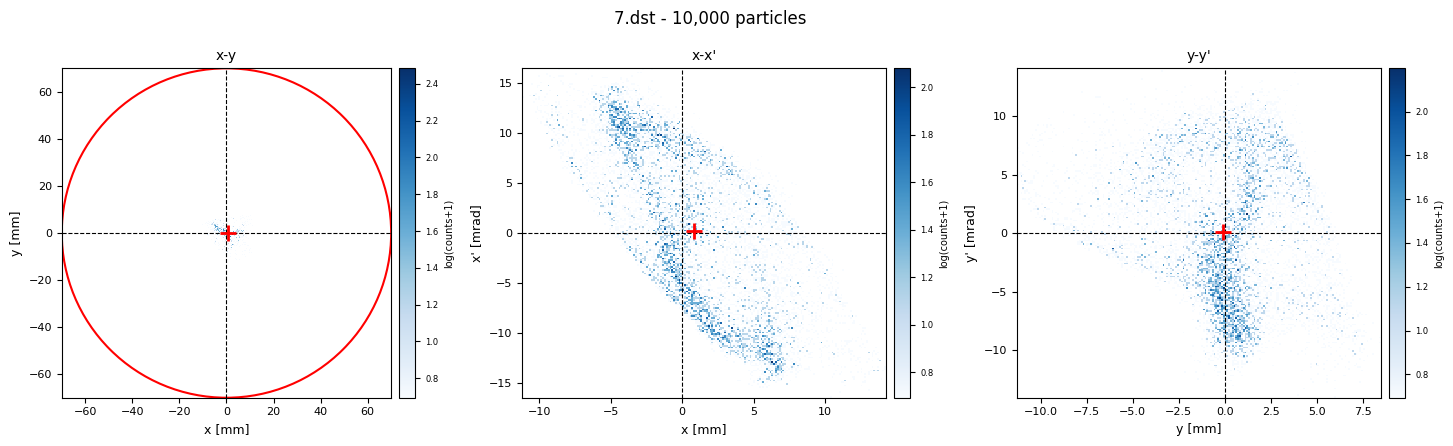

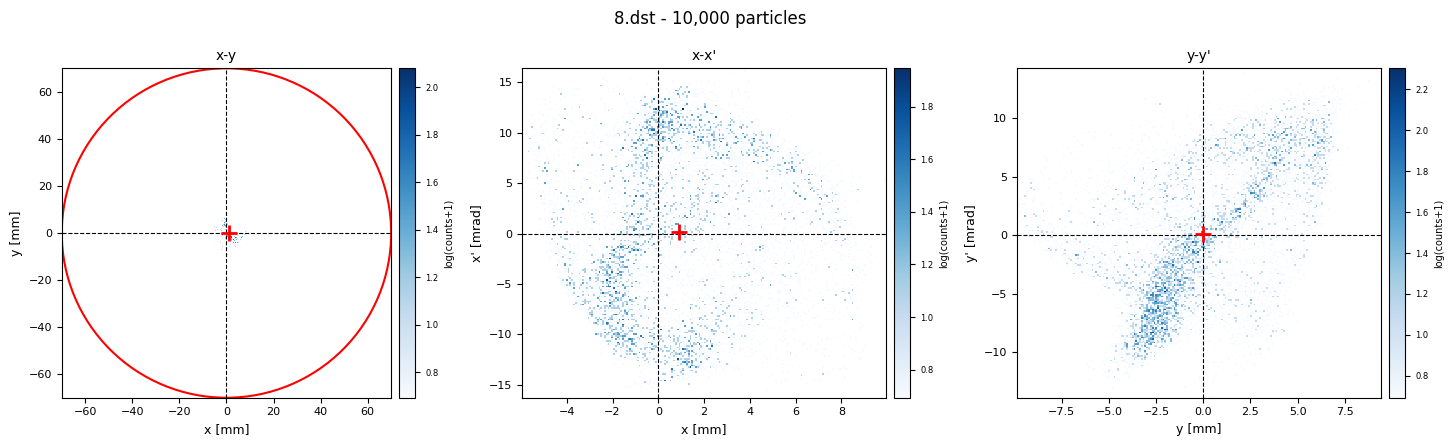

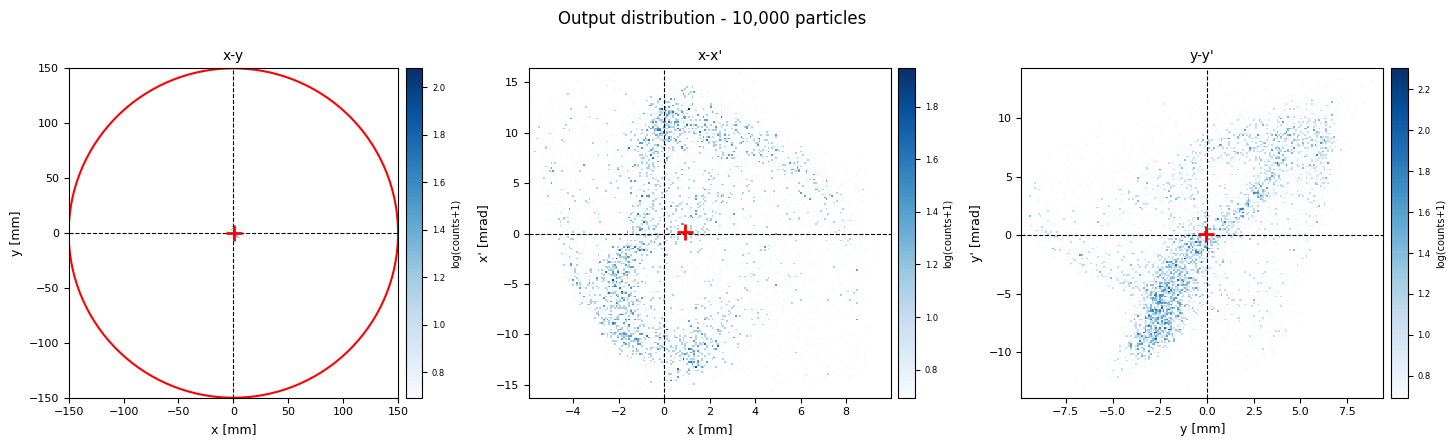

In [5]:
# Draw one figure for each distribution.
# Input/output use readable endpoint titles; intermediate snapshots use their calc filename.
for i, item in enumerate(distributions):
    dst = item['dst']

    if item['role'] == 'input':
        aper_mm = df['Aper'].iloc[0]
        subtitle = f"{dst.Np:,} particles in reservoir, {NPART_SIMULATED:,} simulated"
    elif item['role'] == 'output':
        aper_mm = df['Aper'].iloc[-1]
        subtitle = f"{dst.Np:,} particles"
    else:
        # If the intermediate file is named 1.dst, 2.dst, ... use that number
        # as an approximate partran row index for the aperture.
        stem = item['path'].stem
        row_index = int(stem) if stem.isdigit() else round(i * (len(df) - 1) / max(len(distributions) - 1, 1))
        row_index = max(0, min(row_index, len(df) - 1))
        aper_mm = df['Aper'].iloc[row_index]
        subtitle = f"{dst.Np:,} particles"

    phase_space_plots(dst, f"{item['title']} - {subtitle}", aper_mm=aper_mm)

## Envelope plot

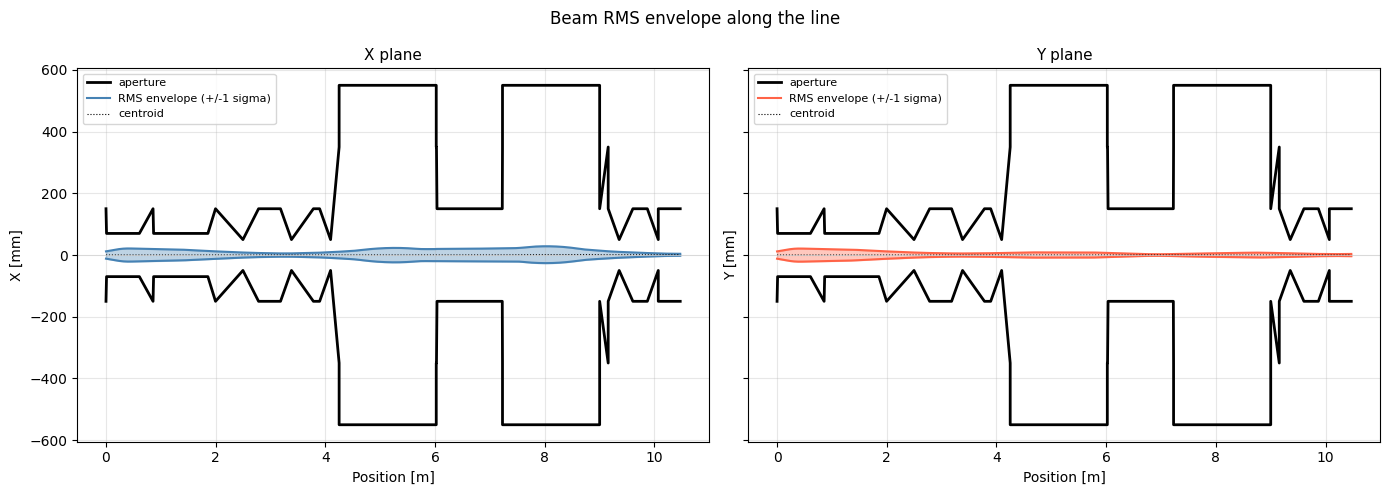

In [6]:
# Envelope plot from partran1.out.
# Black curves are aperture walls; colored bands show centroid +/- RMS size.
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, plane, centroid_col, size_col, color in [
    (axes[0], 'X', 'x0', 'SizeX', 'steelblue'),
    (axes[1], 'Y', 'y0', 'SizeY', 'tomato'),
]:
    c0 = df[centroid_col]
    size = df[size_col]
    aper = df['Aper']

    ax.plot(z, aper, color='black', linewidth=2.0, label='aperture')
    ax.plot(z, -aper, color='black', linewidth=2.0)

    ax.fill_between(z, c0 - size, c0 + size, alpha=0.35, color=color)
    ax.plot(z, c0 + size, color=color, linewidth=1.5, label='RMS envelope (+/-1 sigma)')
    ax.plot(z, c0 - size, color=color, linewidth=1.5)
    ax.plot(z, c0, color='black', linewidth=0.8, linestyle=':', label='centroid')

    ax.axhline(0, color='lightgray', lw=0.5)
    ax.set_xlabel('Position [m]', fontsize=10)
    ax.set_ylabel(f'{plane} [mm]', fontsize=10)
    ax.set_title(f'{plane} plane', fontsize=11)
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(True, alpha=0.3)

plt.suptitle('Beam RMS envelope along the line', fontsize=12)
plt.tight_layout()
plt.show()